# 02 — Feature engineering esteso

## Obiettivi didattici

Aggiungere feature richieste dal PW: propensione conversione, varietà esplorazione, sensibilità prezzo, recente vs storico. Tutte calcolate rispetto alla `as_of_date` (anti-leakage).

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from ecom_clustering.data import load_raw, filter_events_until
from ecom_clustering.features import compute_user_features, select_user_modeling_features
from ecom_clustering.config import DEFAULT_CONFIG
ecom = load_raw()
as_of = ecom.time_max - pd.Timedelta(days=30)
events_history = filter_events_until(ecom.events, as_of)
feats = compute_user_features(events_history, as_of, recent_window_days=14,
                              user_universe=ecom.users.user_id)
print(f'Feature shape: {feats.shape}')
feats.head(5)

Feature shape: (1200, 17)


,recency_days,frequency,monetary,has_purchased,n_add_to_cart,n_purchase,n_view,conversion_rate,cart_to_purchase_rate,n_categories_viewed,n_products_viewed,avg_price_viewed,avg_price_purchased,price_sensitivity_ratio,n_recent_interactions,n_recent_purchases,recent_to_total_ratio
user_id,,,,,,,,,,,,,,,,,
1,274.022824,0,0.00,0,0.0,0.0,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0.000000
2,120.599201,1,97.59,1,4.0,1.0,73.0,0.012821,0.250000,6,64,135.549041,97.590000,0.719961,2,0,0.025641
3,274.022824,0,0.00,0,0.0,0.0,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0.000000
4,274.022824,0,0.00,0,6.0,0.0,158.0,0.000000,0.000000,10,137,84.606139,0.000000,0.000000,12,0,0.073171
5,1.549410,27,1234.07,1,206.0,27.0,2330.0,0.010535,0.131068,15,907,93.889961,45.706296,0.486807,173,2,0.067499


## Le feature richieste dal PW

| Feature | Cattura |
|---|---|
| `conversion_rate` | propensione alla conversione |
| `cart_to_purchase_rate` | aggressività carrello → ordine |
| `n_categories_viewed`, `n_products_viewed` | varietà di esplorazione |
| `avg_price_viewed`, `avg_price_purchased`, `price_sensitivity_ratio` | sensibilità prezzo |
| `n_recent_*`, `recent_to_total_ratio` | comportamento recente vs storico |


In [2]:
modeling_cols = select_user_modeling_features(feats)
print(f'{len(modeling_cols)} feature numeriche di modellazione')
feats[modeling_cols].describe().T

16 feature numeriche di modellazione


,count,mean,std,min,25%,50%,75%,max
recency_days,1200.0,156.427813,119.504158,0.021933,23.149769,173.846574,274.022824,274.022824
frequency,1200.0,4.324167,10.054767,0.000000,0.000000,1.000000,3.000000,80.000000
monetary,1200.0,211.728692,557.389137,0.000000,0.000000,7.665000,107.647500,5263.910000
n_view,1200.0,322.585833,611.028609,0.000000,51.000000,109.500000,255.250000,4684.000000
n_add_to_cart,1200.0,22.164167,45.763805,0.000000,2.000000,6.000000,16.000000,365.000000
n_purchase,1200.0,4.324167,10.054767,0.000000,0.000000,1.000000,3.000000,80.000000
conversion_rate,1200.0,0.007134,0.009351,0.000000,0.000000,0.004175,0.012649,0.100000
cart_to_purchase_rate,1200.0,0.126068,0.181853,0.000000,0.000000,0.074176,0.202127,2.000000
n_categories_viewed,1200.0,9.352500,4.700176,0.000000,7.000000,10.000000,13.000000,15.000000
n_products_viewed,1200.0,190.251667,243.285316,0.000000,48.750000,99.500000,209.500000,1299.000000


## Visualizzazione: alcune relazioni

Ci aspettiamo che `conversion_rate` correli con `frequency`, ma non in modo banale.

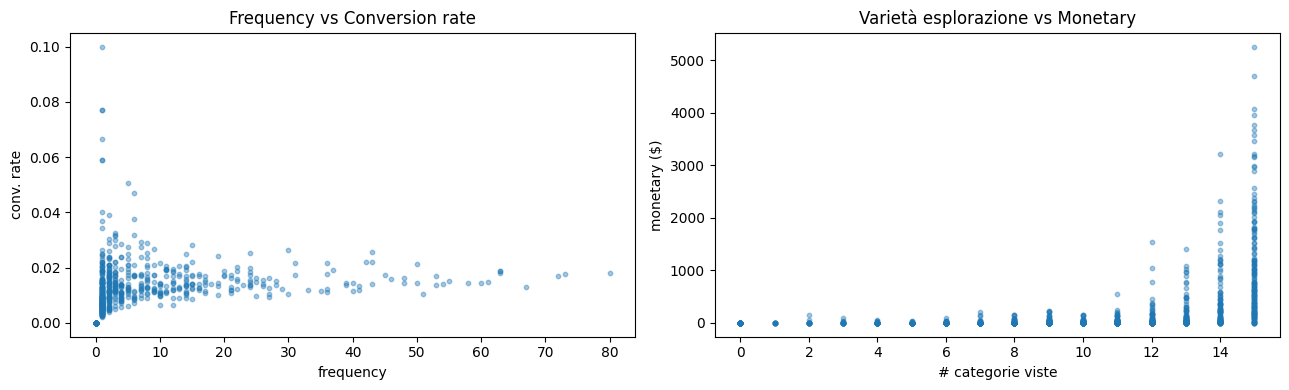

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(feats.frequency, feats.conversion_rate, alpha=0.4, s=10)
axes[0].set(title='Frequency vs Conversion rate', xlabel='frequency', ylabel='conv. rate')
axes[1].scatter(feats.n_categories_viewed, feats.monetary, alpha=0.4, s=10)
axes[1].set(title='Varietà esplorazione vs Monetary',
           xlabel='# categorie viste', ylabel='monetary ($)')
fig.tight_layout(); plt.show()